In [1]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
from datetime import date
path = "/home/jovyan/work/data/bronze/Polars/"

In [2]:
!ls $path

complete_fraud_data.parquet


A continuación procederemos a analizar el volumen de dinero defraudado, dado que los datos estan sesgados en el tiempo, primero analizaremos el volumen total con respecto al año 2010, y los promedios con todo el conjunto no sesgado

In [11]:
amountchip_fraud_unbiased_df = (
    pl.scan_parquet(f"{path}complete_fraud_data.parquet")
    .with_columns(day = pl.col("date").cast(pl.Date))
    .filter(
        ((pl.col("day").is_between(date(2010, 1, 1), date(2011, 1, 8))) |
         (pl.col("day").is_between(date(2013, 7, 19), date(2014, 4, 8))) |
         (pl.col("day").is_between(date(2015, 3, 30), date(2016, 12, 22)))
        ) &
        (pl.col("day") != date(2016, 2, 29)) &
        (pl.col("target").is_not_null())
    )
    .with_columns(
        target = pl.when(pl.col("target")).then(pl.lit("Fraudulent")).otherwise(pl.lit("Legitimate"))
    )
    .select("amount", "target", "use_chip", "day", "client_id")
)

Rows = amountchip_fraud_unbiased_df.select(pl.len()).collect().item()
Columns = len(amountchip_fraud_unbiased_df.collect_schema().names())

print(f"Rows: {Rows}, Columns: {Columns}")
amountchip_fraud_unbiased_df.show(5)

Rows: 3128626, Columns: 5


amount,target,use_chip,day,client_id
f64,str,cat,date,str
10.64,"""Legitimate""","""Swipe Transaction""",2010-01-01,"""822"""
6.71,"""Legitimate""","""Swipe Transaction""",2010-01-01,"""1147"""
-90.0,"""Legitimate""","""Swipe Transaction""",2010-01-01,"""1541"""
8.6,"""Legitimate""","""Swipe Transaction""",2010-01-01,"""148"""
72.85,"""Legitimate""","""Swipe Transaction""",2010-01-01,"""1248"""


In [15]:
chip_evolution_df = (
    amountchip_fraud_unbiased_df
    .group_by("use_chip", "day", "target") 
    .len()
    .sort("use_chip", "day", "target")
    .collect()
)

chip_evolution_df.show(10)

use_chip,day,target,len
cat,date,str,u32
"""Chip Transaction""",2015-03-30,"""Fraudulent""",1
"""Chip Transaction""",2015-03-30,"""Legitimate""",1922
"""Chip Transaction""",2015-03-31,"""Legitimate""",1887
"""Chip Transaction""",2015-04-01,"""Legitimate""",1869
"""Chip Transaction""",2015-04-02,"""Legitimate""",1692
"""Chip Transaction""",2015-04-03,"""Fraudulent""",1
"""Chip Transaction""",2015-04-03,"""Legitimate""",1685
"""Chip Transaction""",2015-04-04,"""Legitimate""",1881
"""Chip Transaction""",2015-04-05,"""Legitimate""",1855


In [16]:
chip_color = {
    'Online Transaction': '#7EA1B5', 
    'Swipe Transaction': '#F2A183', 
    'Chip Transaction': '#89D3C2'
}

chip_order = ["Online Transaction", "Chip Transaction", "Swipe Transaction"]

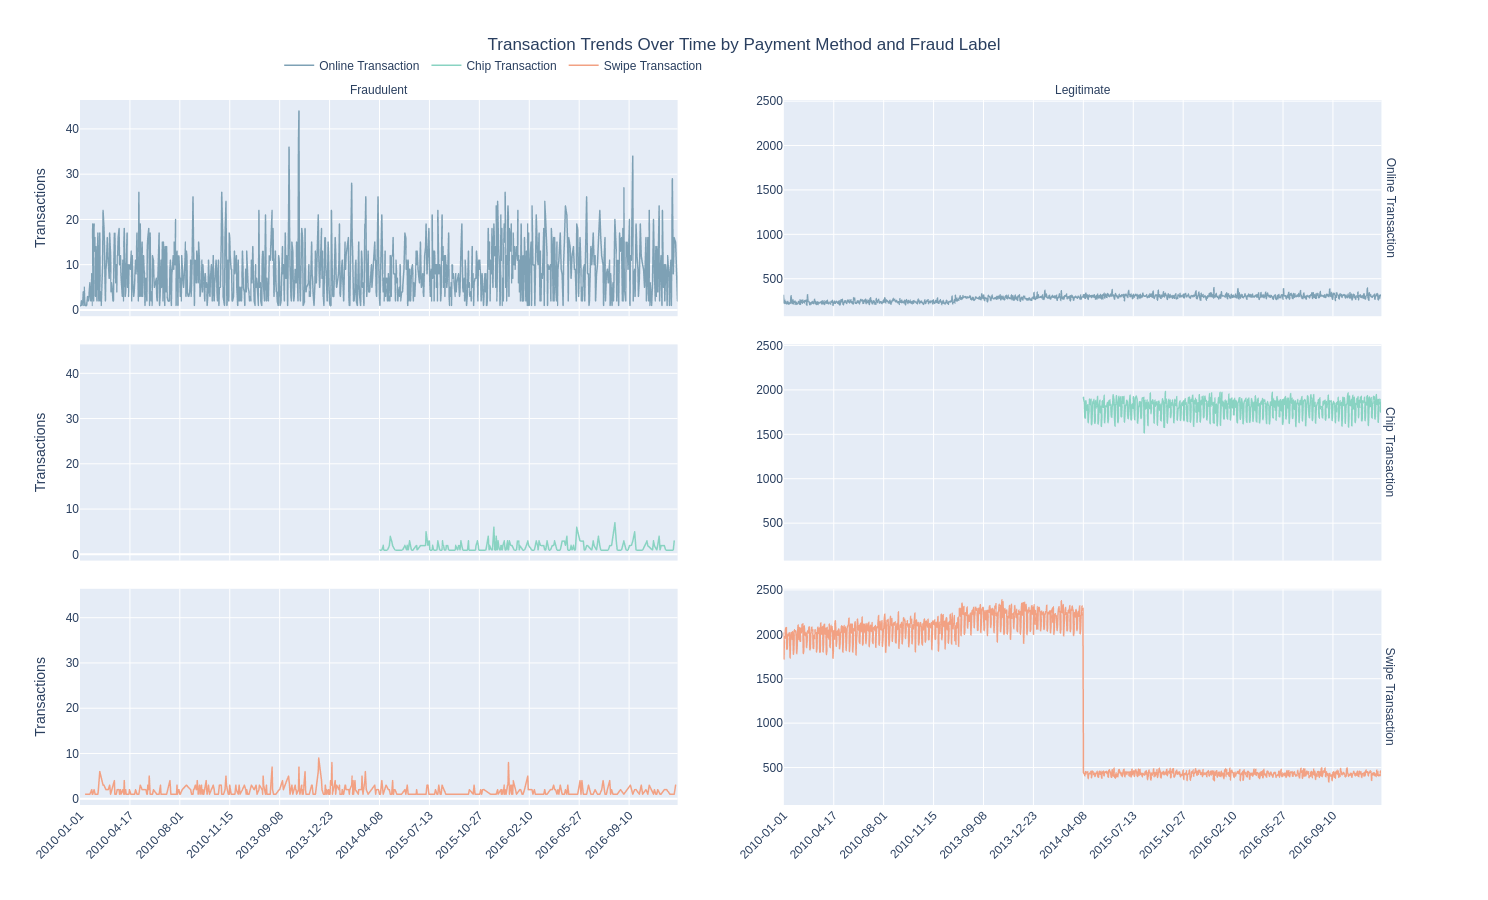

In [20]:
ordered_days = chip_evolution_df['day'].unique().sort()

chip_evolution_plot = px.scatter(
    chip_evolution_df,
    x="day",          
    y="len",
    color="use_chip",
    facet_col="target",         
    facet_row="use_chip",   
    facet_row_spacing=0.04,    
    facet_col_spacing=0.08,     
    title="Transaction Trends Over Time by Payment Method and Fraud Label",
    labels={"day": "", "len": "Transactions", "target": "Is Fraud?"},
    color_discrete_map= chip_color,
    category_orders={"use_chip": chip_order},
    custom_data=["target"]     
)

chip_evolution_plot.update_traces(
    mode="lines",               
    line=dict(width=1.5),   
    hovertemplate="<b>Date:</b> %{x|%A, %d %b %Y}<br><b>Transactions:</b> %{y:,}<extra></extra>"
)

chip_evolution_plot.update_yaxes(
    showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404"
)
    
chip_evolution_plot.update_yaxes(matches="y", showticklabels=True, col=1)
chip_evolution_plot.update_yaxes(matches="y2",showticklabels=True, col=2)

chip_evolution_plot.update_xaxes(
    showticklabels=True, tickformat='%b %Y', matches="x", tickangle=-45, nticks=12,
    type='category', categoryorder='array', categoryarray=ordered_days,
    showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404",
) 

chip_evolution_plot.update_xaxes(showticklabels=False, row=2)
chip_evolution_plot.update_xaxes(showticklabels=False, row=3)

chip_evolution_plot.update_layout(
    title_x=0.5,
    width=900, height=900, autosize=False,                
    hovermode="x",     
    legend=dict(title="", orientation="h", yanchor="top", y=1.07, xanchor="left", x=0.15),
)

chip_evolution_plot.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))

chip_evolution_plot.show()


Debido a que hay tendencias que no se entiendo más que como falta de registros por sesgos seleccionaremos filtraremos nuestros datos para analizarlos durante elperiodo de un año-, el periodo elegido es de 30 de Marzo de 2015 a 29 de Marzo de 2016. Ya que antes de esa fecha no hay registro de transacciones con chip, lo cual puede entorpecer el modelado. Además de que a partir de esa fecha se observa un amplio descenso en el número de operaciones swipe, sin embargo esto no va de la mano con un descenso en el número de registros de fraude, por lo que a priori se fortalece la idea de que hay un error en el registro.  
Buscar cuando salio nueva tarjeta para uso de pin

In [21]:
amountchip_fraud_unbiased2_df = (
    amountchip_fraud_unbiased_df.filter(pl.col("day").is_between(date(2015, 3, 30), date(2016, 3, 29)))
)

amountchip_fraud_unbiased2_df.show(5)

amount,target,use_chip,day,client_id
f64,str,cat,date,str
100.0,"""Legitimate""","""Swipe Transaction""",2015-04-11,"""241"""
2.57,"""Legitimate""","""Chip Transaction""",2015-04-12,"""920"""
45.78,"""Legitimate""","""Chip Transaction""",2015-04-10,"""480"""
542.96,"""Legitimate""","""Chip Transaction""",2015-04-10,"""1811"""
84.12,"""Legitimate""","""Chip Transaction""",2015-04-11,"""52"""


In [29]:
total_amountchip_df = (
    amountchip_fraud_unbiased2_df
    .group_by("target", "use_chip")
    .agg(
        total_transactions = pl.col("amount").len(),
        total_amount = pl.col("amount").sum().round(2)
    )
    .sort("total_amount", descending = True)
    .collect()
)

total_amountchip_df.show(10)

target,use_chip,total_transactions,total_amount
str,cat,u32,f64
"""Legitimate""","""Chip Transaction""",660037,2.6893e7
"""Legitimate""","""Online Transaction""",112161,6.3423e6
"""Legitimate""","""Swipe Transaction""",157719,6.3288e6
"""Fraudulent""","""Online Transaction""",2491,328862.82
"""Fraudulent""","""Chip Transaction""",240,25300.37
"""Fraudulent""","""Swipe Transaction""",183,19764.05


In [30]:
def total_chip_plot (df, y_total, y_axis):
    total_amountchip_plot = px.bar(
        df, 
        x="use_chip", 
        y=y_total, 
        color="use_chip",
        facet_row="target",             
        facet_row_spacing=0.1,         
        color_discrete_map=chip_color,
        category_orders={"use_chip": chip_order},
        text_auto=",",
        custom_data=["target"]         
    )
    
    total_amountchip_plot.update_layout(
        plot_bgcolor="white", paper_bgcolor="white", showlegend=True, 
        width=600, height=600, autosize=False,                     
        margin=dict(l=80, r=30, t=60, b=50),  
        title=dict(text="<b>Fiscal Year 2016 Transaction Breakdown by Payment Method</b>", x=0.5, font=dict(size=14, color="black")),  
        legend=dict(title="", orientation="v", yanchor="top", y=1.05, xanchor="left", x=0.8) 
    )
    
    total_amountchip_plot.update_traces(
        marker_line_color="#4A4A4A", marker_line_width=1.2,
        textposition="outside", textfont=dict(size=11, color="black"), width=0.5,
        hovertemplate="<b>%{x}</b><br>Status: %{customdata[0]}<br>Total: %{y:,}<extra></extra>"
    )
    
    total_amountchip_plot.update_yaxes(
        title= y_axis,
        gridcolor="#EAEAEA", showline=False, zeroline=False, 
        tickfont=dict(size=11, color="black"),
        matches=None, showticklabels=True
    )
    
    total_amountchip_plot.update_xaxes(
        title="", showgrid=False, linecolor="#D3D3D3", 
        tickfont=dict(size=11, color="black", weight="bold"),
        showticklabels=True
    )
    
    total_amountchip_plot.for_each_annotation(
        lambda a: a.update(
            text="<b>Legitimate</b>" if "Legitimate" in a.text 
            else ("<b>Fraudulent</b>" if "Fraudulent" in a.text 
            else f"<b>{a.text.split('=')[-1]}</b>")
        )
    )
    
    return total_amountchip_plot

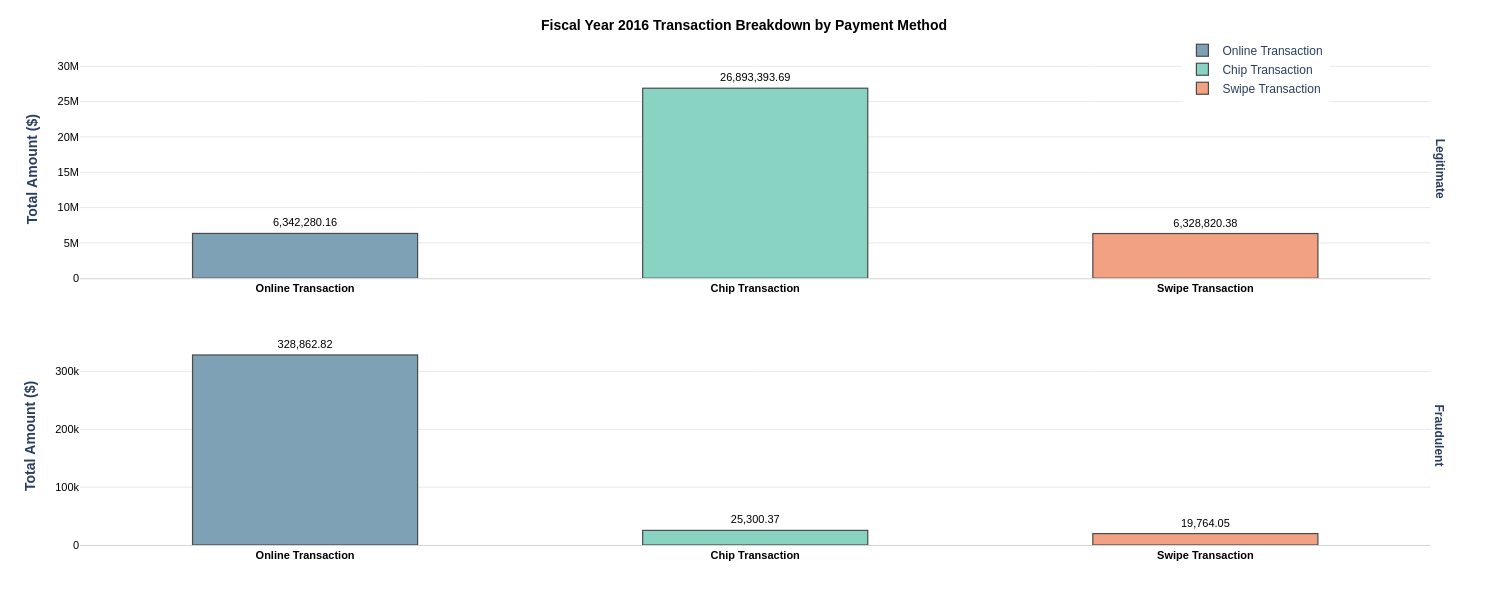

In [31]:
total_chip_plot (total_amountchip_df, "total_amount", "<b>Total Amount ($)</b>")

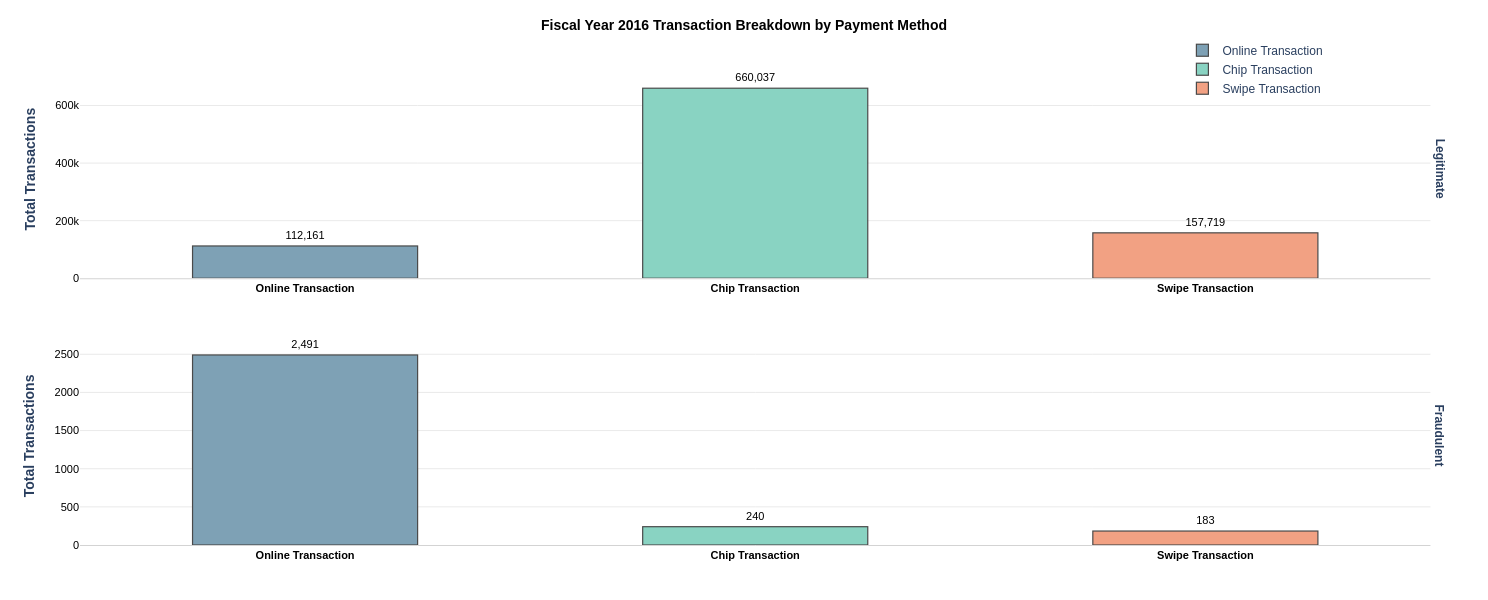

In [32]:
total_chip_plot (total_amountchip_df, "total_transactions", "<b>Total Transactions</b>")

In [37]:
ratio_fraud = (
    total_amountchip_df
    .pivot(
        on="target", index="use_chip", values="total_transactions", aggregate_function="sum"
    )
    .with_columns(
        Frauds_per_10k_Transactions =
            pl.col("Fraudulent") / (pl.col("Fraudulent") + pl.col("Legitimate")) * 10000
    )
    .sort("Frauds_per_10k_Transactions", descending = True)
)

ratio_fraud.show()

use_chip,Legitimate,Fraudulent,Frauds_per_10k_Transactions
cat,u32,u32,f64
"""Online Transaction""",112161,2491,217.266162
"""Swipe Transaction""",157719,183,11.589467
"""Chip Transaction""",660037,240,3.634838


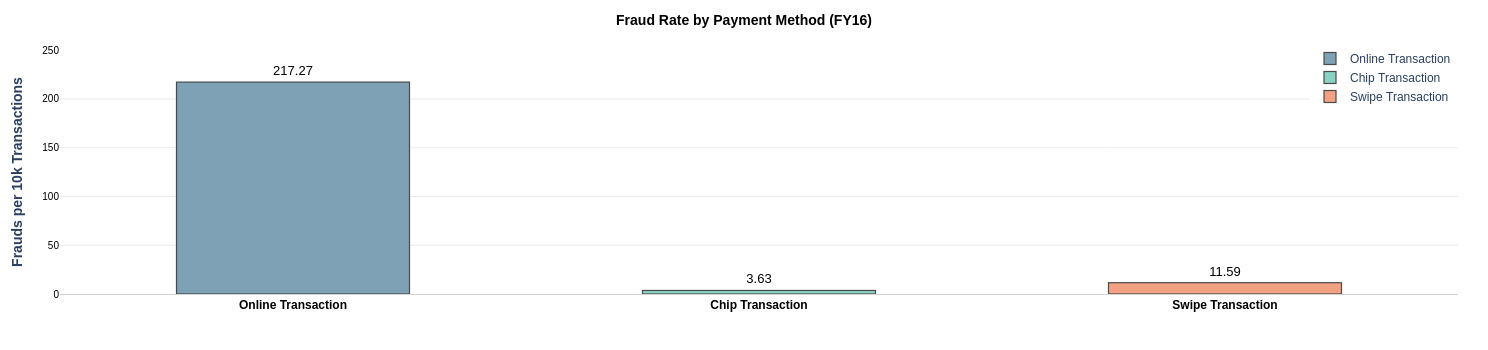

In [38]:
ratio_fraud_plot = px.bar(
    ratio_fraud, 
    x="use_chip", 
    y="Frauds_per_10k_Transactions", 
    color="use_chip",
    color_discrete_map= chip_color,
    category_orders={"use_chip": chip_order},
    text_auto=",.2f" 
)

ratio_fraud_plot.update_layout(
    plot_bgcolor="white", paper_bgcolor="white", showlegend=True, 
    width=600, height=350, autosize=False, margin=dict(l=60, r=30, t=50, b=50), 
    title=dict(text="<b>Fraud Rate by Payment Method (FY16)</b>", x=0.5, font=dict(size=14, color="black"),),     
    xaxis=dict(title="", showgrid=False, linecolor="#D3D3D3", tickfont=dict(size=12, color="black", weight="bold")),    
    yaxis=dict(title="<b>Frauds per 10k Transactions</b>", gridcolor="#EAEAEA", showline=False, zeroline=False,
               tickfont=dict(size=10, color="black")),   
    legend=dict(title="", orientation="v", yanchor="bottom", y=0.75, xanchor="right", x=1),    
)

ratio_fraud_plot.update_traces(
    marker_line_color="#4A4A4A", marker_line_width=1.2,
    textposition="outside", textfont=dict(size=13, color="black"),
    width=0.5,
    hovertemplate="<b>%{x}</b><br>Total: %{y:,}$<extra></extra>"
)

ratio_fraud_plot.show()


In [58]:
true_amountchip_fraud_unbiased2_df = (
    amountchip_fraud_unbiased2_df
    .filter(pl.col("target") == 'Fraudulent')
    .drop("day")
    .collect()
)

false_amountchip_fraud_unbiased2_df = (
    amountchip_fraud_unbiased2_df
    .filter(pl.col("target") == 'Legitimate')
    .drop("day")
    .collect()
    .sample(fraction=0.004, seed=777)
)

sample_amountchip_fraud_unbiased2_df = pl.concat(
    [false_amountchip_fraud_unbiased2_df, true_amountchip_fraud_unbiased2_df]
)

print(f"Rows: {sample_amountchip_fraud_unbiased2_df.height}")

Rows: 6633


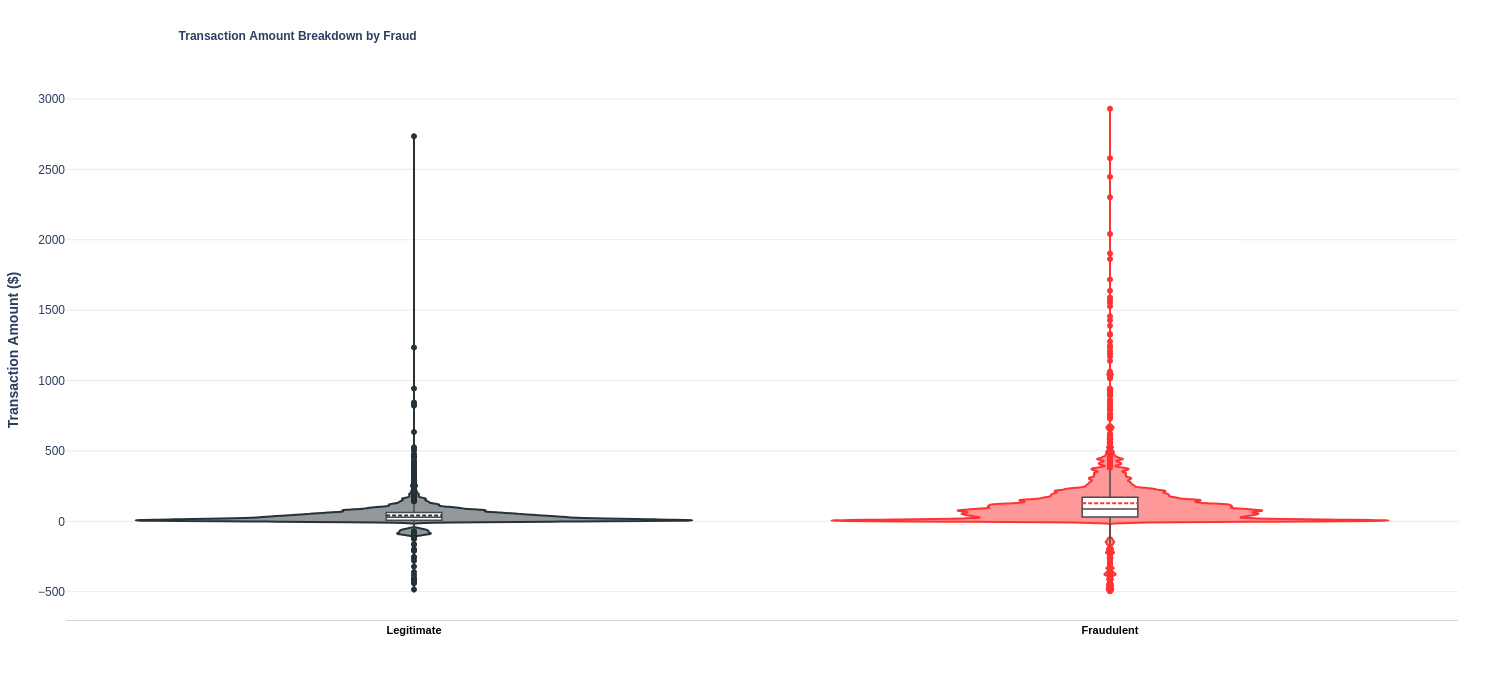

In [64]:
fig_violin = px.violin(
    sample_amountchip_fraud_unbiased2_df,
    x="target",
    y="amount", 
    color="target",        
    points="outliers",
    labels={"amount": "Transaction Amount ($)", "target": "Is Fraud?"},
    color_discrete_map={'Legitimate': '#263238', 'Fraudulent': '#FF3333'},
    box=True,
)

fig_violin.update_traces(
    box_fillcolor="white", box_line_color="#4A4A4A", box_line_width=1.5, box_width=0.1, 
    meanline_visible=True,
    width=0.8, bandwidth=6, 
    # hoveron="violins",    
)

fig_violin.update_layout(
    plot_bgcolor="white", paper_bgcolor="white", showlegend=False,
    width=900, height=700, margin=dict(l=60, r=30, t=80, b=80),
    title=dict(text="<b>Transaction Amount Breakdown by Fraud</b>", x=0.12,font=dict(size=12),),
    xaxis=dict(title="", showgrid=False, linecolor="#D3D3D3", tickfont=dict(size=11, color="black", weight="bold")),
    yaxis=dict(title="<b>Transaction Amount ($)</b>", gridcolor="#EAEAEA", showline=False, zeroline=False),   
)

fig_violin.show()

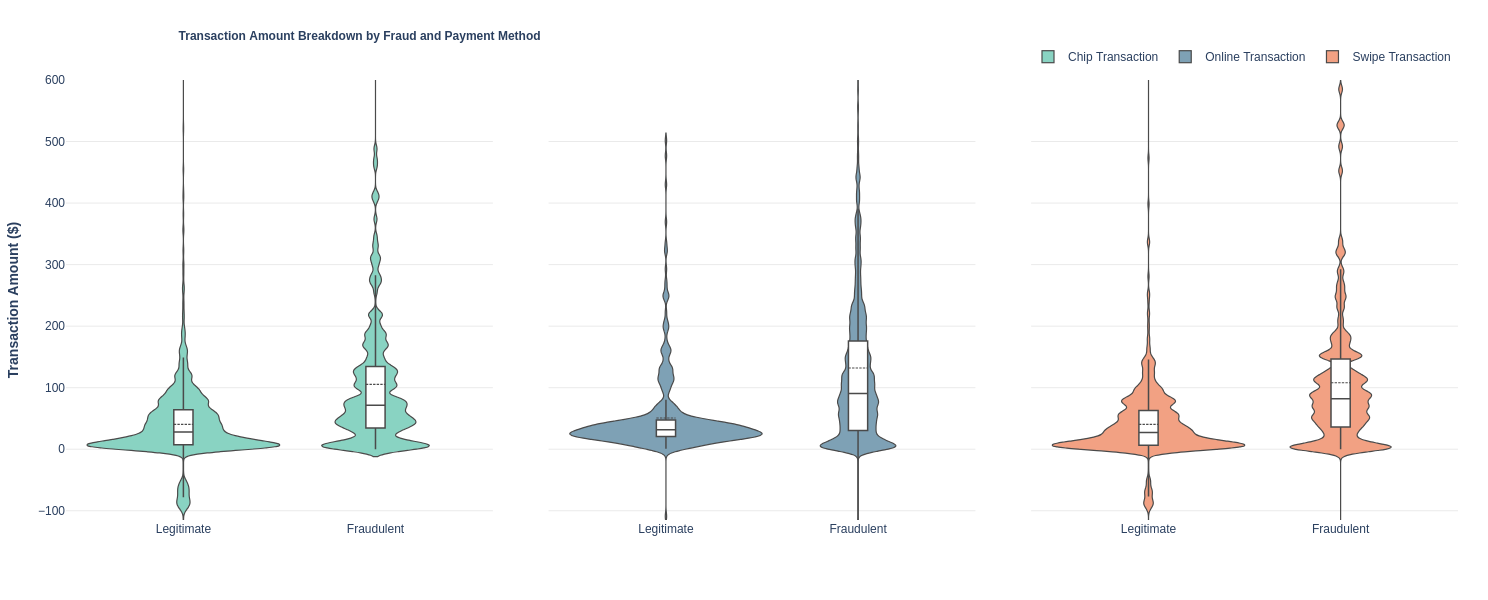

In [65]:
fig = px.violin(
    sample_amountchip_fraud_unbiased2_df,  
    x="target",  
    y="amount",  
    color="use_chip", 
    facet_col="use_chip",             
    facet_col_spacing=0.04,
    color_discrete_map=chip_color, 
    category_orders={"target": chip_order},
    box=True,  
    points=False,
)

fig.update_layout(
    violinmode="group", boxmode="group",
    plot_bgcolor="white", paper_bgcolor="white", showlegend=True,
    width=900, height=600, autosize=False, margin=dict(l=60, r=30, t=80, b=80),
    title=dict(text="<b>Transaction Amount Breakdown by Fraud and Payment Method</b>", 
               x=0.12,font=dict(size=12),),
    legend=dict(title="", orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    yaxis=dict(title="<b>Transaction Amount ($)</b>", gridcolor="#EAEAEA", showline=False, 
               zeroline=False, 
               range=[-115, 600] 
              ),   
)

fig.update_traces(
    box_fillcolor="white", box_line_color="#4A4A4A", box_line_width=1.5, box_width=0.1, 
    meanline_visible=True,
    line=dict(color="#4A4A4A", width=1.2),    
    width=1,
    bandwidth=6, 
    hoveron="violins",    
)

fig.update_yaxes(showgrid=True, gridcolor="#EAEAEA", showline=False, zeroline=False)
fig.update_xaxes(title_text="")
fig.update_annotations(text="")

fig.for_each_trace(lambda trace: trace.update(fillcolor=chip_color.get(trace.name, "#CCCCCC")))
  
fig.show()


Analizamos el historial de transacciones de algunos clientes

In [67]:
fraudulent_client_df = (
    amountchip_fraud_unbiased_df 
    .select("client_id", "target")
    .filter(pl.col("target") == 'Fraudulent')
    .unique()
    .collect()
)

fraudulent_client_list = fraudulent_client_df["client_id"].to_list()
print("Total Clients with Fraudulent Transactions:", len(fraudulent_client_list))

Total Clients with Fraudulent Transactions: 1045


In [68]:
client_df = (
    amountchip_fraud_unbiased_df
    .filter(pl.col("client_id").is_in(fraudulent_client_list))
    .select("client_id", "day", "amount", "use_chip", "target")
)

Rows_client = client_df.select(pl.len()).collect().item()
Columns_client = len(client_df.collect_schema().names())

print(f"Rows: {Rows_client}, Columns: {Columns_client}")
client_df.show(5)

Rows: 2728092, Columns: 5


client_id,day,amount,use_chip,target
str,date,f64,cat,str
"""822""",2010-01-01,10.64,"""Swipe Transaction""","""Legitimate"""
"""1147""",2010-01-01,6.71,"""Swipe Transaction""","""Legitimate"""
"""1541""",2010-01-01,-90.0,"""Swipe Transaction""","""Legitimate"""
"""148""",2010-01-01,8.6,"""Swipe Transaction""","""Legitimate"""
"""1248""",2010-01-01,72.85,"""Swipe Transaction""","""Legitimate"""


In [80]:
def plot_client_behaviour_amount(client_ID):
    client_transaction_df = (
        client_df
        .filter(pl.col("client_id") == client_ID)
        .sort("day")
        .with_columns(
            hover_date_str = pl.col("day").dt.to_string("%A, %d %b %Y"),
            amount_absolute = pl.col("amount").abs(),
            amount_sign = pl.when(pl.col("amount") >= 0).then(pl.lit("Positive")).otherwise(pl.lit("Negative")),
            day_str = pl.col("day").dt.to_string("%Y-%m-%d")
        )
        .collect() 
    )
    
    client_transaction_fig = px.scatter(
        client_transaction_df,
        x="day_str",        
        y="amount",    
        color="target",
        facet_row="use_chip",         
        facet_row_spacing=0.08,                      
        opacity=0.6,
        category_orders={"target": ["Legitimate", "Fraudulent"]},
        custom_data=["hover_date_str", "use_chip"],
        title= f"<b>Transactions Behaviour, ClientID: {client_ID}</b>",
        labels={"day_str": "Date"}
    )
    
    client_transaction_fig.update_traces(
        marker=dict(line=dict(color='black', width=0.45)),
        hovertemplate="<b>%{customdata[0]}</b><br>Chip: %{customdata[1]}\
        <br>amount: %{y:,.2f}$<extra></extra>"
    )
    
    client_transaction_fig.update_layout(
        plot_bgcolor="#F5F5F5", paper_bgcolor="white", 
        height=750, width=900, autosize=False,
        legend=dict(title="", orientation="h", yanchor="top", y=1.08, xanchor="left", x=0.65)
    )
    
    client_transaction_fig.update_xaxes(
        showticklabels=True, tickformat="%A, %d %b %Y", matches="x", tickangle=-45, nticks=12,
        type='category', categoryorder='array', categoryarray=ordered_days,
        showspikes=True, spikemode='across', spikethickness=1, spikedash='dash', spikecolor="#040404",
    
    ) 
    
    client_transaction_fig.update_xaxes(showticklabels=False, row=2)
    client_transaction_fig.update_xaxes(showticklabels=False, row=3)
    
    client_transaction_fig.update_yaxes(showgrid=True, gridcolor="#EAEAEA")
    
    client_transaction_fig.for_each_annotation(lambda a: a.update(
        text=f"<b>{a.text.split('=')[-1]}</b>",
        font=dict(size=14, color="black")
        )
    )
    
    client_transaction_fig.add_vline(x="2011-01-08", line_width=1.5, line_dash="dash")
    client_transaction_fig.add_vline(x="2015-03-30", line_width=1.5, line_dash="dash")
    
    return client_transaction_fig


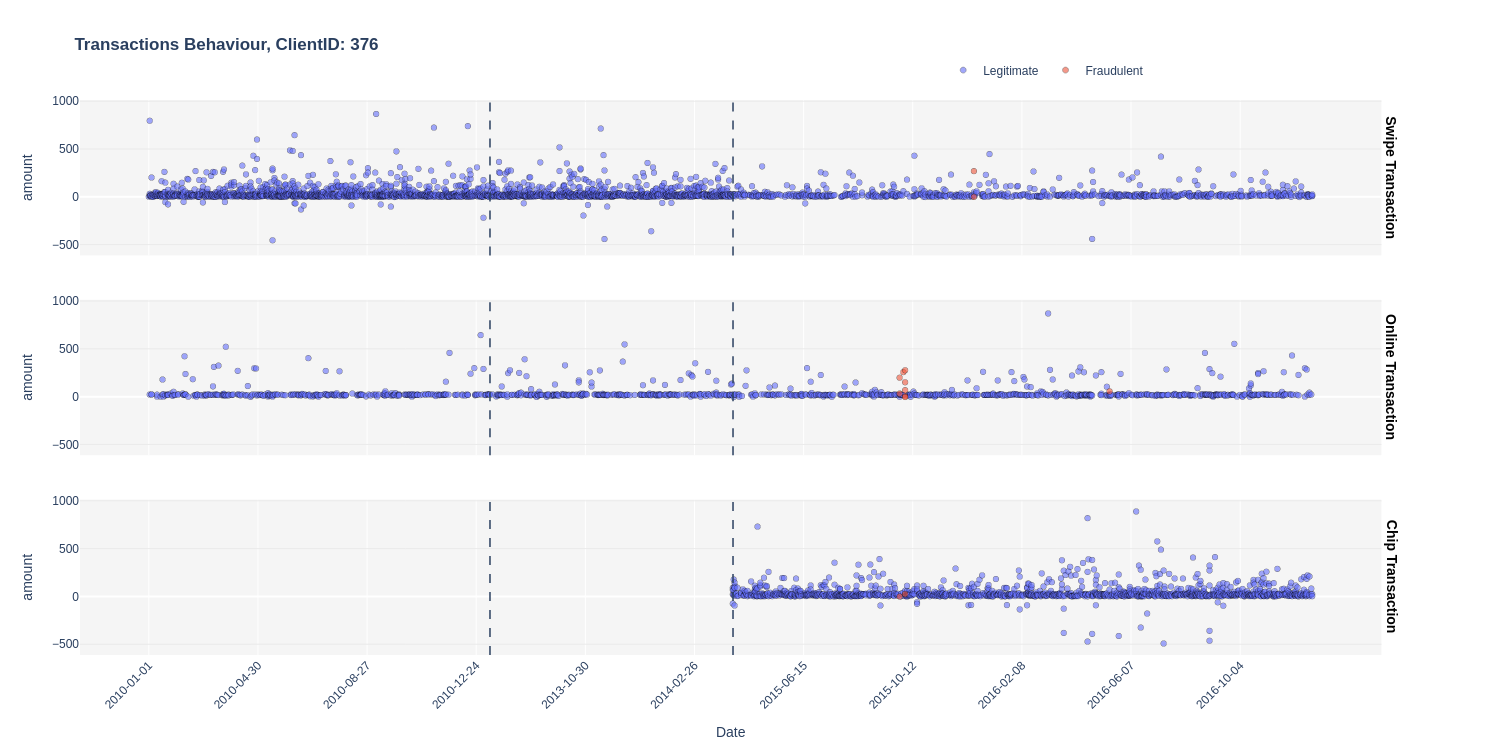

In [81]:
plot_client_behaviour_amount("376")

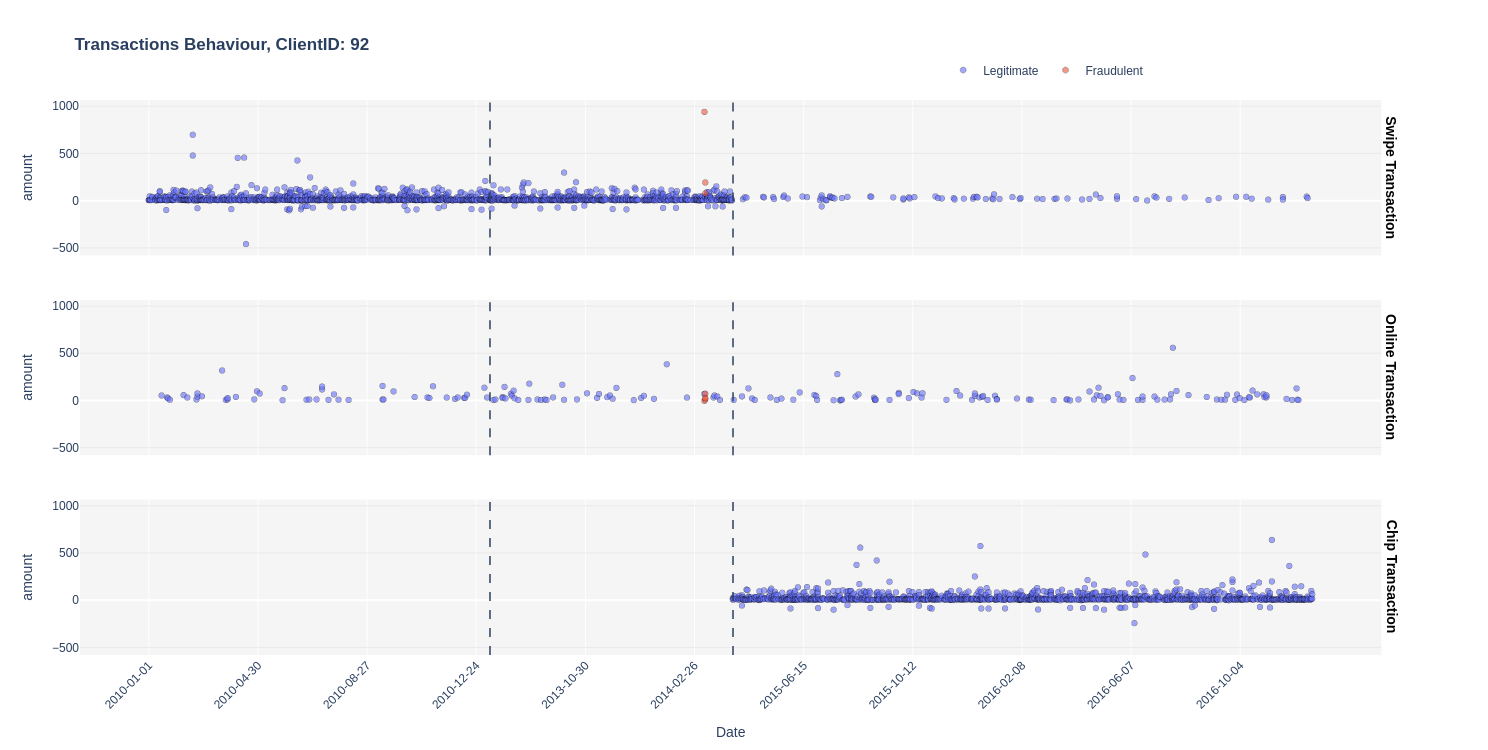

In [83]:
plot_client_behaviour_amount(fraudulent_client_list[1])

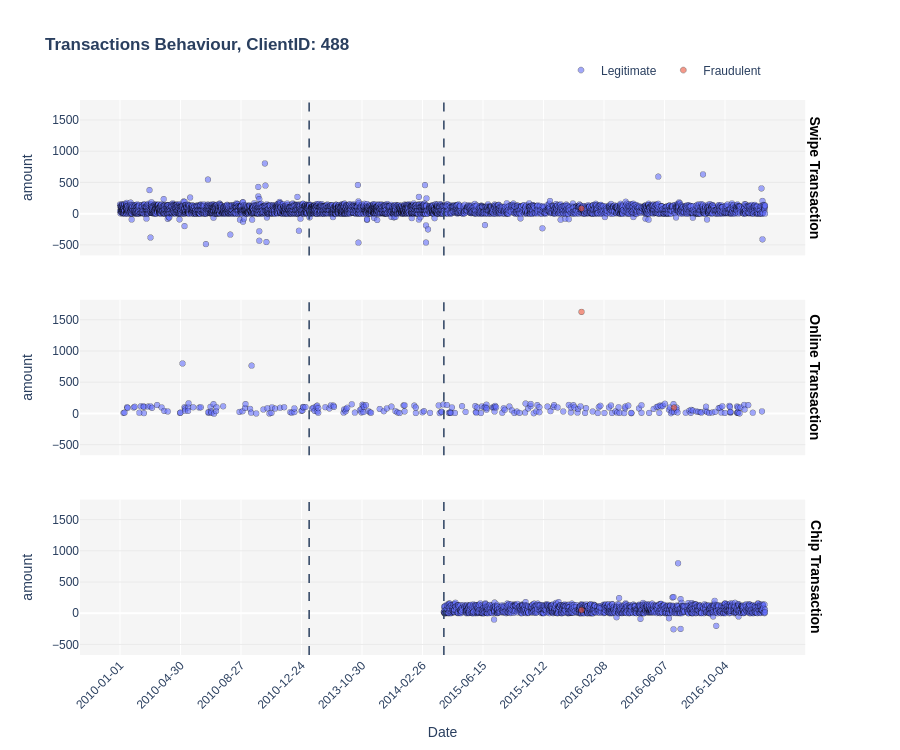

In [84]:
plot_client_behaviour_amount(fraudulent_client_list[2])